# Cybersecurity Network Traffic Anomaly Detection

**Objective:** Prioritize unusual network flows from volume, duration, ports, failed connections, byte ratios, and fan-out behavior.

This notebook trains without labels. A small injected scenario flag is retained only to test the alerting workflow after scoring.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Generate normal behavior and rare stress scenarios


In [2]:
FEATURES = ["bytes_mb", "duration_seconds", "destination_ports", "failed_connections", "upload_ratio", "destination_hosts"]
MEANS = np.asarray([2.5, 18, 2, 0.3, 0.35, 3], dtype=float)
STDS = np.asarray([1.1, 7, 0.8, 0.6, 0.12, 1.2], dtype=float)
SHIFTS = np.asarray([8, 5, 10, 12, 4, 10], dtype=float)

normal = rng.normal(MEANS, STDS, size=(960, len(FEATURES)))
stress = rng.normal(MEANS + SHIFTS * STDS, STDS * 0.55, size=(40, len(FEATURES)))
values = np.vstack([normal, stress])
values = np.maximum(values, 0)
data = pd.DataFrame(values, columns=FEATURES)
data["scenario_anomaly"] = np.r_[np.zeros(len(normal), dtype=int), np.ones(len(stress), dtype=int)]
data = data.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset: {len(data):,} windows | stress scenarios retained for retrospective checks: {data['scenario_anomaly'].sum()}")
display(data.head().round(3))
display(data[FEATURES].describe().T.round(3))


Dataset: 1,000 windows | stress scenarios retained for retrospective checks: 40


,bytes_mb,duration_seconds,destination_ports,failed_connections,upload_ratio,destination_hosts,scenario_anomaly
0,2.453,20.890,1.419,0.522,0.430,2.196,0
1,0.936,13.130,1.197,0.737,0.370,1.331,0
2,2.866,2.892,1.970,0.000,0.362,1.707,0
3,3.940,27.382,2.414,0.027,0.321,2.035,0
4,2.015,27.258,2.530,0.310,0.295,2.480,0


,count,mean,std,min,25%,50%,75%,max
bytes_mb,1000.0,2.849,2.047,0.0,1.824,2.554,3.299,12.940
duration_seconds,1000.0,19.096,10.033,0.0,13.004,18.245,22.721,62.734
destination_ports,1000.0,2.289,1.765,0.0,1.435,2.025,2.591,11.117
failed_connections,1000.0,0.714,1.454,0.0,0.000,0.322,0.809,8.559
upload_ratio,1000.0,0.370,0.150,0.0,0.274,0.356,0.441,0.935
destination_hosts,1000.0,3.462,2.685,0.0,2.184,3.102,3.878,16.127


## 3. Robust scaling and label-free detector fitting


In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X = scaler.fit_transform(data[FEATURES])
contamination = 0.04

isolation = IsolationForest(n_estimators=240, contamination=contamination, random_state=RANDOM_STATE, n_jobs=1)
data["isolation_flag"] = (isolation.fit_predict(X) == -1).astype(int)
data["isolation_score"] = -isolation.score_samples(X)

lof = LocalOutlierFactor(n_neighbors=35, contamination=contamination)
data["lof_flag"] = (lof.fit_predict(X) == -1).astype(int)
data["lof_score"] = -lof.negative_outlier_factor_
print(f"Isolation Forest alerts: {data['isolation_flag'].sum()} | LOF alerts: {data['lof_flag'].sum()}")


Isolation Forest alerts: 40 | LOF alerts: 40


## 4. Retrospective detector diagnostics


In [4]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

rows = []
for name in ["isolation", "lof"]:
    rows.append({
        "detector": name,
        "precision": precision_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "recall": recall_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "f1": f1_score(data["scenario_anomaly"], data[f"{name}_flag"], zero_division=0),
        "roc_auc_from_score": roc_auc_score(data["scenario_anomaly"], data[f"{name}_score"]),
    })
diagnostics = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(diagnostics.round(4))
print("Scenario labels were not used during scaling, detector fitting, or threshold selection.")


Scenario labels were not used during scaling, detector fitting, or threshold selection.


,detector,precision,recall,f1,roc_auc_from_score
0,isolation,1.0,1.0,1.0,1.0000
1,lof,0.0,0.0,0.0,0.2221


## 5. Alert queue and feature-level context


In [5]:
median = data[FEATURES].median()
mad = (data[FEATURES] - median).abs().median().replace(0, 1e-9)
robust_deviation = ((data[FEATURES] - median) / mad).abs()
data["largest_deviation_feature"] = robust_deviation.idxmax(axis=1)
data["largest_robust_deviation"] = robust_deviation.max(axis=1)
alerts = data.sort_values("isolation_score", ascending=False).head(12)
display(alerts[FEATURES + ["isolation_score", "largest_deviation_feature", "largest_robust_deviation", "scenario_anomaly"]].round(3))


,bytes_mb,duration_seconds,destination_ports,failed_connections,upload_ratio,destination_hosts,isolation_score,largest_deviation_feature,largest_robust_deviation,scenario_anomaly
388,10.187,47.288,10.292,6.583,0.911,13.797,0.731,failed_connections,19.431,1
251,11.810,49.579,10.462,8.559,0.680,15.459,0.725,failed_connections,25.562,1
561,10.715,47.341,10.099,8.032,0.843,14.087,0.718,failed_connections,23.929,1
662,10.424,57.780,9.820,7.037,0.935,14.956,0.714,failed_connections,20.840,1
872,11.772,52.918,10.500,7.934,0.909,15.796,0.708,failed_connections,23.624,1
657,10.960,49.108,10.833,7.654,0.868,15.583,0.707,failed_connections,22.755,1
616,10.526,57.276,9.779,7.286,0.915,15.764,0.706,failed_connections,21.614,1
117,11.579,60.769,10.078,8.308,0.842,15.015,0.705,failed_connections,24.784,1
767,11.523,60.603,10.395,7.423,0.885,16.126,0.705,failed_connections,22.036,1
43,12.171,55.821,10.423,7.977,0.868,14.976,0.704,failed_connections,23.758,1


## 6. Two-dimensional anomaly map


Detector score correlation: 0.3963


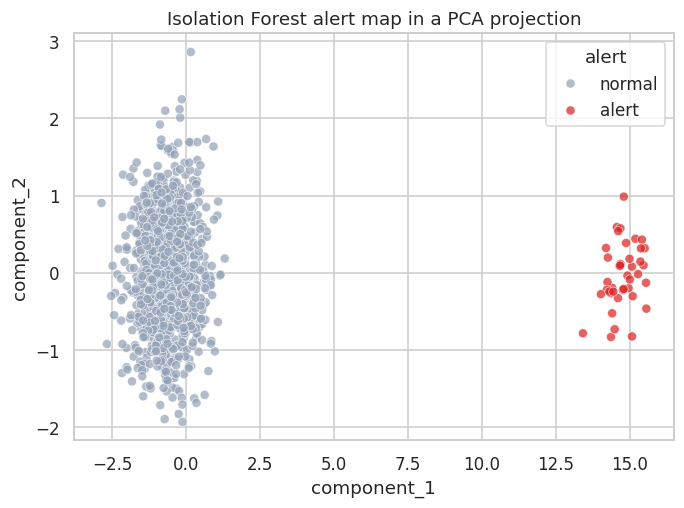

In [6]:
from sklearn.decomposition import PCA

projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_data = pd.DataFrame({"component_1": projection[:, 0], "component_2": projection[:, 1], "alert": data["isolation_flag"].map({0: "normal", 1: "alert"})})
sns.scatterplot(data=plot_data, x="component_1", y="component_2", hue="alert", palette={"normal": "#94a3b8", "alert": "#dc2626"}, alpha=0.72)
plt.title("Isolation Forest alert map in a PCA projection")
plt.tight_layout()
plt.show()
print(f"Detector score correlation: {data[['isolation_score', 'lof_score']].corr().iloc[0, 1]:.4f}")


## 7. Findings and limitations

- Anomaly scores prioritize investigation; they do not prove malicious activity, failure, or waste.
- The injected stress cases demonstrate evaluation mechanics only.
- Production thresholds should be calibrated to alert capacity, missed-event cost, seasonality, and feedback from investigators.
